# Prototype exctract data 

In [32]:
import copernicusmarine
from copernicusmarine import subset
import os 
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt 
import numpy as np
import sys 


# Set

In [33]:
# Set
year = 2024

start_month = '01'
start_day = '01'

end_month = '01'
end_day = '10'

product_name = 'cmems_mod_med_phy-tem_anfc_4.2km_P1D-m'
export_path = "../data/raw"

minimum_longitude = 13.141159647873394
maximum_longitude = 13.8238
minimum_latitude  = 45.4698
maximum_latitude  = 45.8078

min_depth = 0.0
max_depth = 1.5

# Automatic 
nc_out = os.path.join(export_path, product_name+ f'_{str(year)}' +".nc")
prq_out = os.path.join(export_path, product_name + f'_{str(year)}' +".parquet")

# Exctract

In [34]:
subset(
    dataset_id = product_name,  
    #variables=["thetao"],  # esempio: variables=["uo","vo"]
    minimum_longitude = minimum_longitude,
    maximum_longitude = maximum_longitude,
    minimum_latitude  = minimum_latitude,
    maximum_latitude  = maximum_latitude,
    start_datetime =    f"{str(year)}-{start_month}-{start_day}T00:00:00",
    end_datetime   =    f"{str(year)}-{end_month}-{end_day}T00:00:00",
    minimum_depth= min_depth,      
    maximum_depth= max_depth, 
    output_filename = nc_out
)

INFO - 2025-10-21T11:24:29Z - Selected dataset version: "202411"
INFO - 2025-10-21T11:24:29Z - Selected dataset part: "default"
WARNING - 2025-10-21T11:24:31Z - Some of your subset selection [0.0, 1.5] for the depth dimension exceed the dataset coordinates [1.0182366371154785, 5754.0439453125]
INFO - 2025-10-21T11:24:33Z - Starting download. Please wait...
100%|██████████| 4/4 [00:00<00:00,  6.45it/s]
INFO - 2025-10-21T11:24:33Z - Successfully downloaded to ../data/raw/cmems_mod_med_phy-tem_anfc_4.2km_P1D-m_2024.nc


ResponseSubset(file_path=PosixPath('../data/raw/cmems_mod_med_phy-tem_anfc_4.2km_P1D-m_2024.nc'), output_directory=PosixPath('.'), filename='cmems_mod_med_phy-tem_anfc_4.2km_P1D-m_2024.nc', file_size=0.022770992366412213, data_transfer_size=3.1423511450381683, variables=['bottomT', 'thetao'], coordinates_extent=[GeographicalExtent(minimum=13.166666984558105, maximum=13.791666984558105, unit='degrees_east', coordinate_id='longitude'), GeographicalExtent(minimum=45.47916793823242, maximum=45.77083206176758, unit='degrees_north', coordinate_id='latitude'), TimeExtent(minimum='2024-01-01T00:00:00+00:00', maximum='2024-01-10T00:00:00+00:00', unit='iso8601', coordinate_id='time'), GeographicalExtent(minimum=1.0182366371154785, maximum=1.0182366371154785, unit='m', coordinate_id='depth')], status='000', message='The request was successful.', file_status='DOWNLOADED')

In [35]:
ds = xr.open_dataset(nc_out)

In [36]:
os.remove(nc_out)

# Convert df

In [37]:
df = ds.to_dataframe().reset_index()

# Plot 

In [38]:
gulf_df = pd.read_csv('../data/raw/ts_gulf_coords.csv')

In [39]:
cpr_unq_coords = df.drop_duplicates(subset=['latitude', 'longitude']).copy()

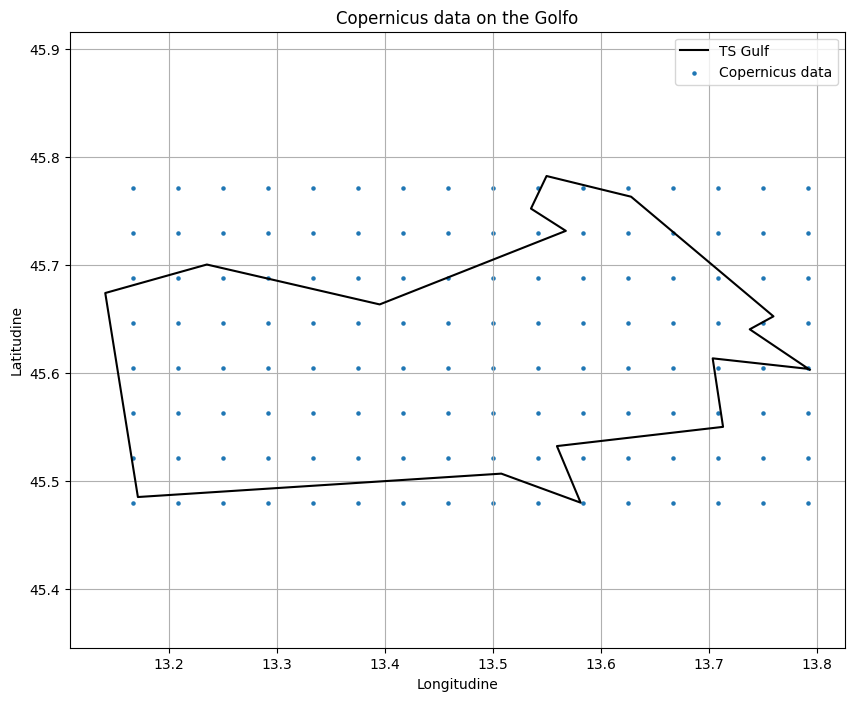

In [ ]:
plt.figure(figsize=(10,8))

plt.plot(gulf_df['longitude'], gulf_df['latitude'], label = 'TS Gulf', color = 'black')
plt.scatter(cpr_unq_coords['longitude'], cpr_unq_coords['latitude'], label = 'Copernicus data', s = 5)
plt.xlim(13,14)
plt.ylim(45.3,45.9)
plt.xlabel("Longitudine")
plt.ylabel("Latitudine")
plt.grid(True)
plt.axis("equal")
plt.legend()
plt.title("Copernicus data")

plt.show()

# Filter see var

In [41]:
marine_col = list(df.columns)[-1]

In [42]:
flt_df = df[df[marine_col].notna()].copy()

In [45]:
flt_cpr_unq_coords = flt_df.drop_duplicates(subset=['latitude', 'longitude']).copy()

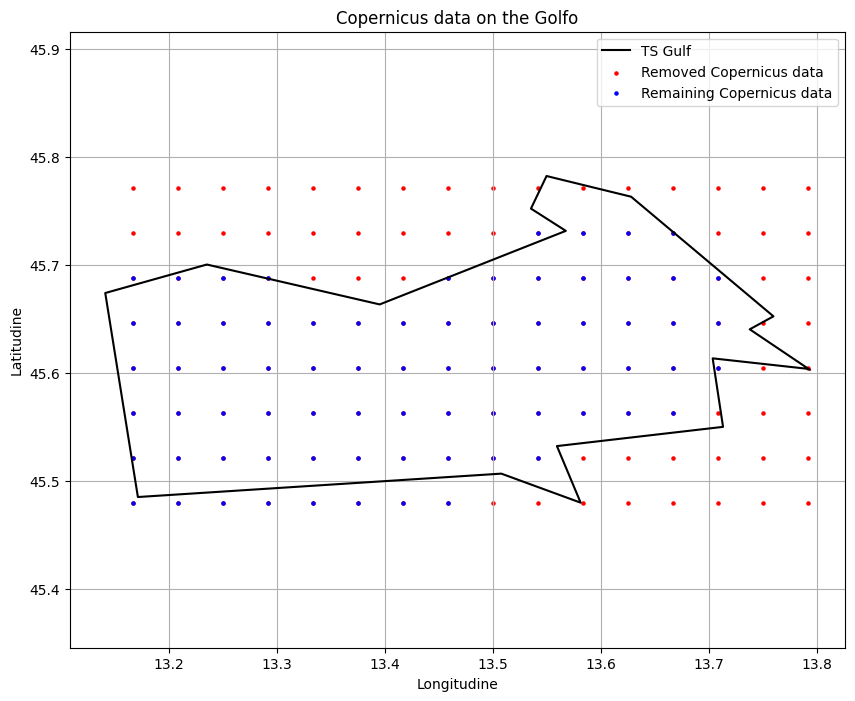

In [ ]:
plt.figure(figsize=(10,8))

plt.plot(gulf_df['longitude'], gulf_df['latitude'], label = 'TS Gulf', color = 'black')
plt.scatter(cpr_unq_coords['longitude'], cpr_unq_coords['latitude'], label = 'Removed Copernicus data', s = 5, color= 'red')
plt.scatter(flt_cpr_unq_coords['longitude'], flt_cpr_unq_coords['latitude'], label = 'Remaining Copernicus data', s = 5, color = 'blue')
plt.xlim(13,14)
plt.ylim(45.3,45.9)
plt.xlabel("Longitudine")
plt.ylabel("Latitudine")
plt.grid(True)
plt.axis("equal")
plt.legend()
plt.title("Copernicus data")

plt.show()

# Export 

In [ ]:
df.to_parquet(prq_out, index=False)